# Data Visualization: context, effective visuals and storytelling 

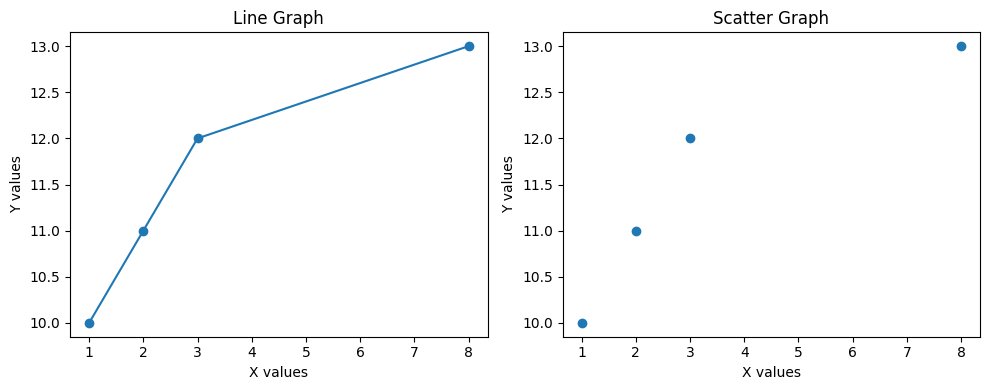

In [2]:
import matplotlib.pyplot as plt
import pandas as pd
plt.style.use('default')

x = [1,2,3,8]
y = [10,11,12,13]

plt.figure(figsize=(10,4))

# First subplot
plt.subplot(1, 2, 1)
plt.plot(x, y, marker='o')
plt.title("Line Graph")
plt.xlabel("X values")
plt.ylabel("Y values")

# Second subplot
plt.subplot(1, 2, 2)
plt.scatter(x, y, marker='o')
plt.title("Scatter Graph")
plt.xlabel("X values")
plt.ylabel("Y values")

plt.tight_layout()
plt.show()

### Q1. For the MTCARS dataset, answer the specified questions with summarization and effective visuals. 

In [3]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

> a. Load the MTCARS dataset and display its basic structure (rows, columns, data types). 

In [4]:
data = pd.read_csv("mtcars.csv")
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32 entries, 0 to 31
Data columns (total 12 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   model   32 non-null     object 
 1   mpg     32 non-null     float64
 2   cyl     32 non-null     int64  
 3   disp    32 non-null     float64
 4   hp      32 non-null     int64  
 5   drat    32 non-null     float64
 6   wt      32 non-null     float64
 7   qsec    32 non-null     float64
 8   vs      32 non-null     int64  
 9   am      32 non-null     int64  
 10  gear    32 non-null     int64  
 11  carb    32 non-null     int64  
dtypes: float64(5), int64(6), object(1)
memory usage: 3.1+ KB


> b. Compute summary statistics (mean, median, min, max) for Miles per gallon (mpg), Horsepower (hp), and Weight (wt).

In [5]:
data[['mpg', 'hp', 'wt']].describe().loc[['mean', '50%', 'min', 'max']]

,mpg,hp,wt
mean,20.090625,146.6875,3.21725
50%,19.200000,123.0000,3.32500
min,10.400000,52.0000,1.51300
max,33.900000,335.0000,5.42400


> c. Identify the relationship between engine cylinders (cyl) and fuel efficiency (mpg) using an appropriate visualization.

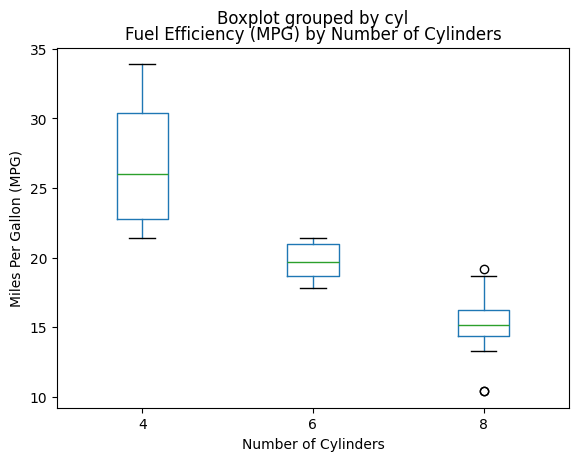

In [6]:
data.boxplot(column='mpg', by='cyl', grid=False)
plt.title('Fuel Efficiency (MPG) by Number of Cylinders')
plt.xlabel('Number of Cylinders')
plt.ylabel('Miles Per Gallon (MPG)')
plt.show()

> d. Create a scatter plot between horsepower (hp) and mpg. Add labels and a meaningful title.

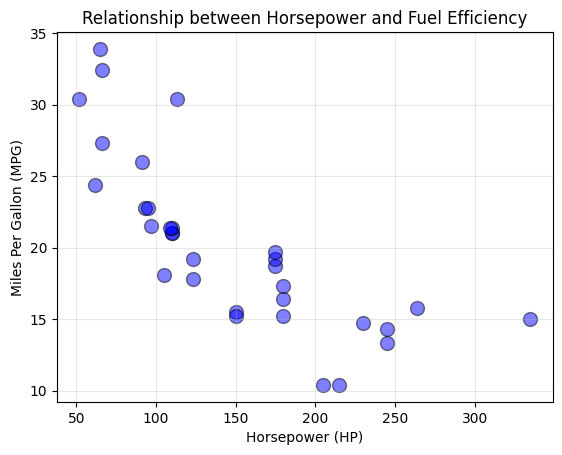

In [7]:
plt.scatter(data['hp'], data['mpg'], alpha=0.5, c='b', edgecolors='black', s=100)
plt.title('Relationship between Horsepower and Fuel Efficiency')
plt.xlabel('Horsepower (HP)')
plt.ylabel('Miles Per Gallon (MPG)')
plt.grid(True, alpha=0.3)
plt.show()

> e. Compare manual vs automatic transmission cars in terms of mpg using a box plot.

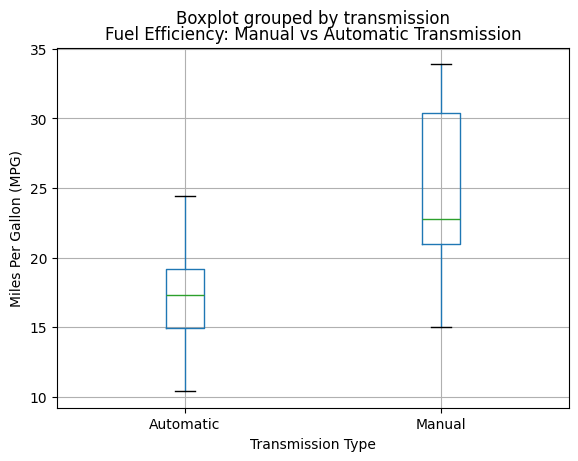

In [8]:
transmission_labels = {0: 'Automatic', 1: 'Manual'}
data['transmission'] = data['am'].map(transmission_labels)

data.boxplot(column='mpg', by='transmission', grid=True)
plt.title('Fuel Efficiency: Manual vs Automatic Transmission')
plt.xlabel('Transmission Type')
plt.ylabel('Miles Per Gallon (MPG)')
plt.show()

> f. Identify which car model gives the best balance of power and fuel efficiency. Justify using a visualization.

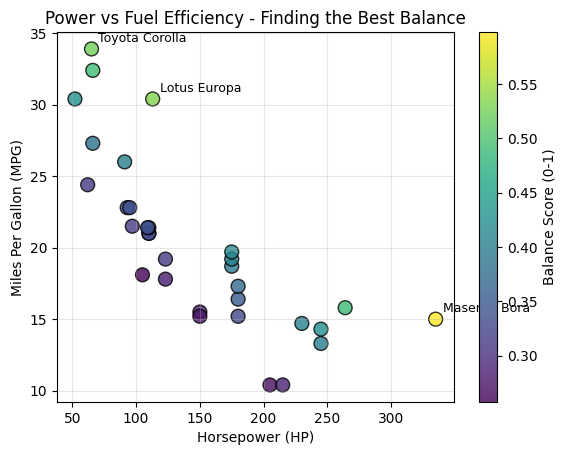

In [9]:
data['hp_normalized'] = (data['hp'] - data['hp'].min()) / (data['hp'].max() - data['hp'].min())
data['mpg_normalized'] = (data['mpg'] - data['mpg'].min()) / (data['mpg'].max() - data['mpg'].min())
data['balance_score'] = (data['mpg_normalized'] + data['hp_normalized']) / 2

scatter = plt.scatter(data['hp'], data['mpg'], c=data['balance_score'], s=100, alpha=0.8, edgecolors='black')
plt.colorbar(scatter, label='Balance Score (0-1)')
plt.title('Power vs Fuel Efficiency - Finding the Best Balance')
plt.xlabel('Horsepower (HP)')
plt.ylabel('Miles Per Gallon (MPG)')
plt.grid(True, alpha=0.3)

top_balanced = data.nlargest(3, 'balance_score')
for idx, row in top_balanced.iterrows():
    plt.annotate(row['model'], (row['hp'], row['mpg']), 
                xytext=(5, 5), textcoords='offset points', fontsize=9)
plt.show()

> g. Write a short data story (3–4 lines) summarizing insights derived from the plots.

**Data Story: The Trade-off Between Power and Efficiency**

The analysis of the MTCARS dataset reveals a clear inverse relationship between power and fuel efficiency. Cars with more cylinders (6-8) and higher horsepower consistently deliver lower fuel efficiency, with a strong negative correlation of approximately -0.78 between horsepower and MPG. Manual transmission vehicles demonstrate significantly better fuel economy than automatics, averaging around 24 MPG compared to 17 MPG for automatics. The scatter plot analysis identifying the best balance of power and efficiency highlights that optimal vehicles achieve moderate horsepower (around 100-150 HP) while maintaining respectable fuel economy (25-30 MPG), suggesting that consumers face a fundamental trade-off between performance and efficiency in their vehicle choices.

# Cereals Analysis

Q1 Load the CEREALS dataset and inspect missing values

In [16]:
cereals = pd.read_csv('Cereals.csv')
cereals.info()
print((cereals == -1).sum() + (cereals == '?').sum())

cereals = cereals.replace("?", np.nan)
cereals = cereals.replace(-1, np.nan)
cereals = cereals.dropna()
cereals[['calories', 'sugars', 'fiber']] = cereals[['calories', 'sugars', 'fiber']].apply(pd.to_numeric, errors='coerce')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 76 entries, 0 to 75
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   name      76 non-null     object 
 1   mfr       76 non-null     object 
 2   type      76 non-null     object 
 3   calories  76 non-null     int64  
 4   protein   76 non-null     int64  
 5   fat       76 non-null     int64  
 6   sodium    76 non-null     int64  
 7   fiber     76 non-null     float64
 8   carbo     76 non-null     object 
 9   sugars    76 non-null     object 
 10  potass    76 non-null     object 
 11  vitamins  76 non-null     int64  
 12  shelf     76 non-null     int64  
 13  weight    76 non-null     float64
 14  cups      76 non-null     float64
 15  rating    76 non-null     float64
dtypes: float64(4), int64(6), object(6)
memory usage: 9.6+ KB
name        0
mfr         0
type        0
calories    0
protein     0
fat         0
sodium      0
fiber       0
carbo       1
sugars 

Q2 Calculate average calories, sugar, and fiber content

In [17]:
print("Average Calories:", cereals['calories'].mean())
print("Average Sugar:", cereals['sugars'].mean())
print("Average Fiber:", cereals['fiber'].mean())

Average Calories: 107.53424657534246
Average Sugar: 7.123287671232877
Average Fiber: 2.0684931506849313


Q3 Create a bar chart showing top 5 cereals with highest sugar content

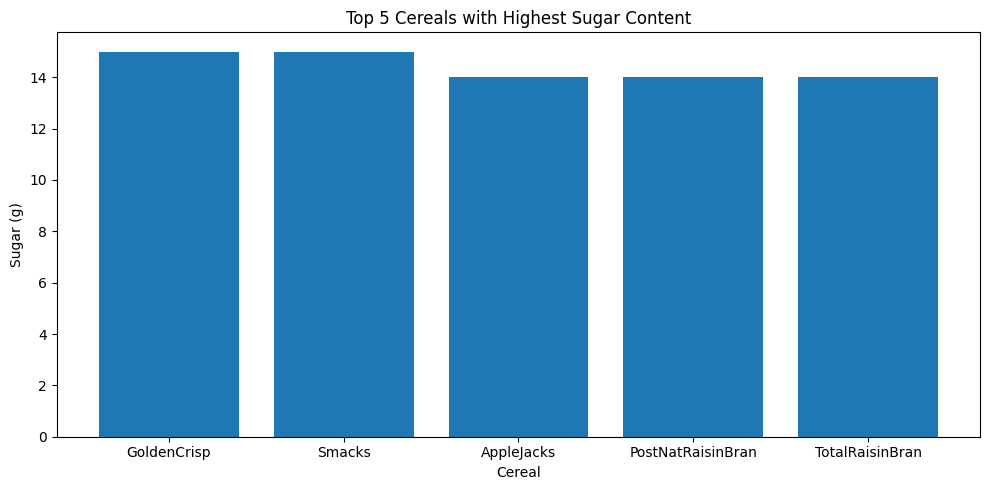

In [18]:
top_5_sugar = cereals.nlargest(5, 'sugars')[['name', 'sugars']]
plt.figure(figsize=(10, 5))
plt.bar(top_5_sugar['name'], top_5_sugar['sugars'])
plt.xlabel('Cereal')
plt.ylabel('Sugar (g)')
plt.title('Top 5 Cereals with Highest Sugar Content')
plt.tight_layout()
plt.show()

Q4 Visualize the relationship between calories and rating

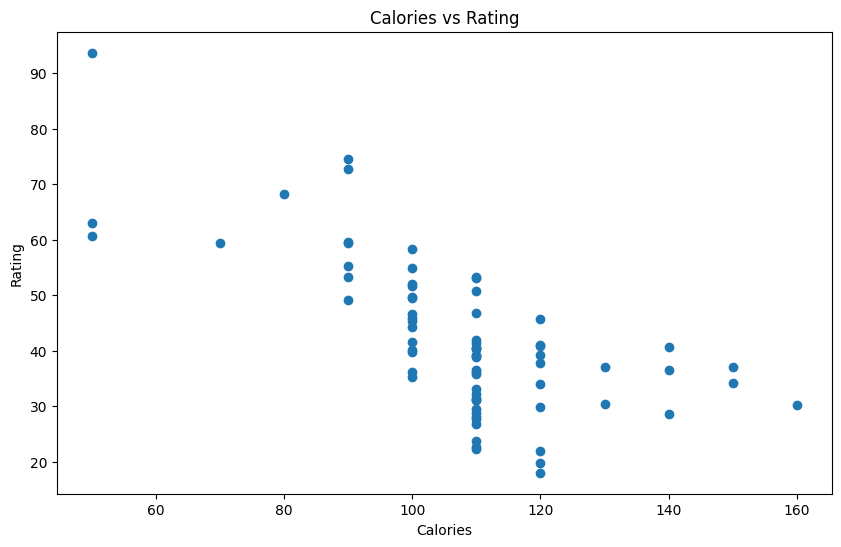

Correlation: -0.6783250079441411


In [19]:
plt.figure(figsize=(10, 6))
plt.scatter(cereals['calories'], cereals['rating'])
plt.xlabel('Calories')
plt.ylabel('Rating')
plt.title('Calories vs Rating')
plt.show()
print("Correlation:", cereals['calories'].corr(cereals['rating']))

Q5 Compare cold vs hot cereals based on calorie distribution

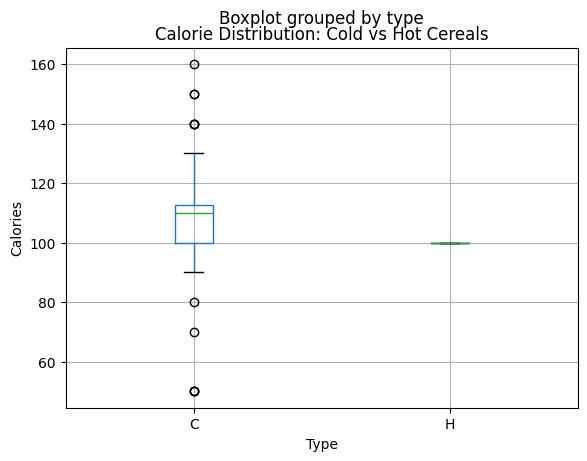

In [20]:
cereals.boxplot(column='calories', by='type')
plt.xlabel('Type')
plt.ylabel('Calories')
plt.title('Calorie Distribution: Cold vs Hot Cereals')
plt.show()

Q6 Identify healthier cereals using at least two nutritional parameters

In [21]:
healthy = cereals[(cereals['sugars'] < 6) & (cereals['fiber'] > 3)].sort_values('rating', ascending=False)
print("Healthier Cereals (Low Sugar & High Fiber):")
print(healthy[['name', 'sugars', 'fiber', 'calories', 'rating']])

Healthier Cereals (Low Sugar & High Fiber):
                      name  sugars  fiber  calories     rating
2   All-BranwithExtraFiber       0   14.0        50  93.704912
63      ShreddedWheatnBran       0    4.0        90  74.472949
1                 All-Bran       5    9.0        70  59.425505
8               BranFlakes       5    5.0        90  53.313813


Q7 Summary with key visualization and explanation

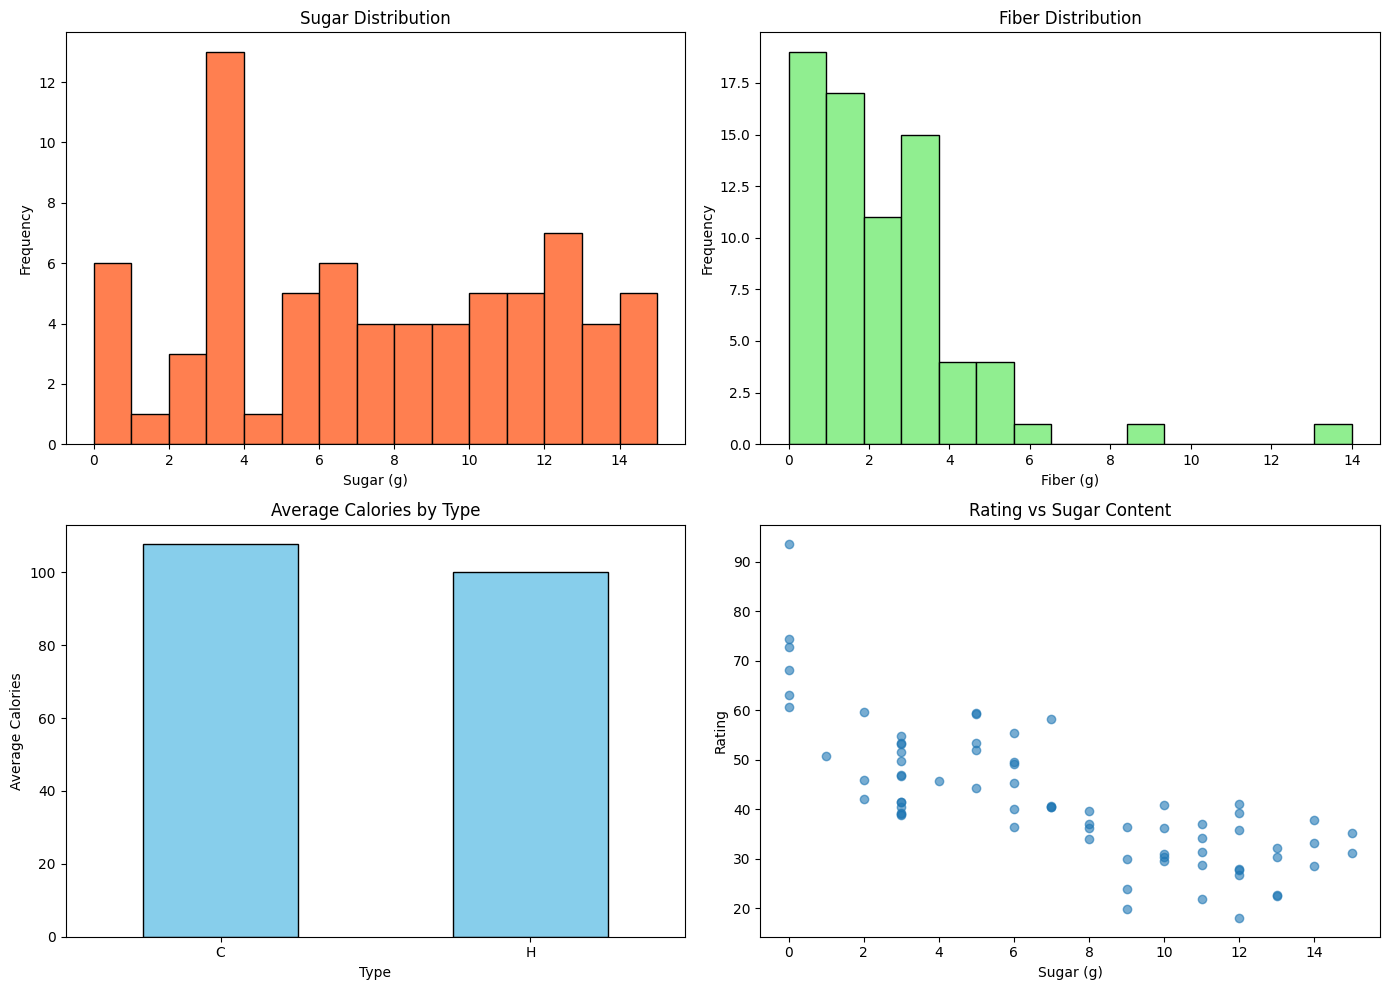


=== KEY FINDINGS ===
1. Most cereals have high sugar content (avg: 7.12g)
2. Only 4 cereals meet 'healthy' criteria (low sugar & high fiber)
3. Hot cereals average 100.0 cal, Cold cereals: 107.6 cal
4. Higher sugar content correlates with lower ratings (r: -0.768)


In [22]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0, 0].hist(cereals['sugars'], bins=15, color='coral', edgecolor='black')
axes[0, 0].set_xlabel('Sugar (g)')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].set_title('Sugar Distribution')

axes[0, 1].hist(cereals['fiber'], bins=15, color='lightgreen', edgecolor='black')
axes[0, 1].set_xlabel('Fiber (g)')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].set_title('Fiber Distribution')

cereals.groupby('type')['calories'].mean().plot(kind='bar', ax=axes[1, 0], color='skyblue', edgecolor='black')
axes[1, 0].set_xlabel('Type')
axes[1, 0].set_ylabel('Average Calories')
axes[1, 0].set_title('Average Calories by Type')
axes[1, 0].tick_params(axis='x', rotation=0)

axes[1, 1].scatter(cereals['sugars'], cereals['rating'], alpha=0.6)
axes[1, 1].set_xlabel('Sugar (g)')
axes[1, 1].set_ylabel('Rating')
axes[1, 1].set_title('Rating vs Sugar Content')

plt.tight_layout()
plt.show()

print("\n=== KEY FINDINGS ===")
print(f"1. Most cereals have high sugar content (avg: {cereals['sugars'].mean():.2f}g)")
print(f"2. Only {len(healthy)} cereals meet 'healthy' criteria (low sugar & high fiber)")
print(f"3. Hot cereals average {cereals[cereals['type']=='H']['calories'].mean():.1f} cal, Cold cereals: {cereals[cereals['type']=='C']['calories'].mean():.1f} cal")
print(f"4. Higher sugar content correlates with lower ratings (r: {cereals['sugars'].corr(cereals['rating']):.3f})")